# Datenaufbereitung — Lehrermangel und Heterogenität in deutschen Schulen

## 1. Thema
**Die unmögliche Aufgabe** – Warum deutsche Lehrer individuelle Förderung nicht leisten können

## 2. Fragestellung
Wie hat sich das Verhältnis zwischen wachsender Heterogenität in deutschen Schulklassen 
und verfügbarer Lehrerkapazität über die letzten 10–15 Jahre entwickelt – und was zeigen 
die Leistungsergebnisse?

## 3. Mein Beitrag: Datenaufbereitung

Ich bin im Team für die **Datenaufbereitung** zuständig. Mein Ziel ist es, alle Rohdaten 
so vorzubereiten, dass die Kollegen sie direkt für ihre Visualisierungen verwenden können.

## 4. Storyline & Organisation der Datensätze

Anstatt alle Daten in eine große Tabelle zu packen, organisiere ich die Daten 
**thematisch** entlang der Storyline der Argumentation:

| Block | Thema | Datensatz |
|-------|-------|-----------|
| **A** | Kapazität | Anzahl Lehrer, Anzahl Schüler |
| **B** | Heterogenität | Schüler mit sonderpädagogischer Förderung |
| **C** | Wahrnehmung der Lehrkräfte | Größte Herausforderungen im Beruf |
| **D** | Wahrnehmung der Schulleitungen | Belastungsfaktoren |
| **E** | Symptome des Mangels | Unbesetzte Lehrkräftestellen, krankheitsbedingte Ausfälle |
| **F** | Leistungsergebnisse | PISA-Ergebnisse (Mathe, Lesen, Naturwissenschaften) |

Jeder Block bekommt eine **eigene saubere CSV-Datei**, damit die 
Visualisierungs-Kollegen gezielt damit arbeiten können.

## 5. Datenquellen

Folgende Quellen werden in diesem Notebook verarbeitet:

   5.1. **Statistisches Bundesamt** — Anzahl Lehrer und Schüler an allgemeinbildenden Schulen
   5.2. **KMK (Kultusministerkonferenz)** — Schüler mit sonderpädagogischer Förderung
   5.3. **OECD** — PISA-Studien (Mathematik, Lesekompetenz, Naturwissenschaften)
   5.4. **Robert Bosch Stiftung** (Schulbarometer 2024) — Umfrage unter Lehrkräften
   5.5. **Verband Bildung und Erziehung (VBE)** — Umfragen unter Schulleitungen

### 5.6. Hinweis zur Extraktion aus dem Statista-Report

Für die Wahrnehmungs-Daten (Blöcke C, D und Teile von E) habe ich den Statista-Report 
*"Lehrkräftemangel in Deutschland"* (2024) genutzt. Da Statista die Rohdaten als 
PDF-Diagramme bereitstellt, habe ich die relevanten Zahlen aus den Diagrammen ausgelesen 
und in eigene Excel-Dateien im **gleichen Format wie die anderen Statista-Dateien** 
(`Übersicht` + `Daten`-Sheet) übertragen. So lassen sich alle Dateien mit derselben 
Hilfsfunktion einlesen.

## 6. Benötigte Bibliotheken importieren

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Standard-Einstellungen für die Diagramme
plt.rcParams['font.size'] = 10

print(f"pandas Version: {pd.__version__}")
print(f"numpy Version:  {np.__version__}")

pandas Version: 2.3.3
numpy Version:  2.3.5


## 7. Pfade zu den Datendateien

Alle Excel-Dateien liegen im Ordner `Statistiken/`. 
Ich definiere die Pfade zentral, damit sie einfach zu ändern sind, falls sich 
Dateinamen ändern.

In [3]:
DATEN_ORDNER = "Statistiken"

# === Block A: Kapazität ===
datei_lehrer       = os.path.join(DATEN_ORDNER, "Lehrer an allgemeinbildenden Schulen.xlsx")
datei_schueler     = os.path.join(DATEN_ORDNER, "Schüler an allgemeinbildenden Schulen.xlsx")

# === Block B: Heterogenität ===
datei_inklusion    = os.path.join(DATEN_ORDNER, "Schüler mit sonderpädagogischer Förderung in allgemeinen Schulen bis 2023.xlsx")

# === Block C: Wahrnehmung der Lehrkräfte ===
datei_herausforderungen = os.path.join(DATEN_ORDNER, "Umfrage Lehrkräfte zu Herausforderungen 2024.xlsx")

# === Block D: Wahrnehmung der Schulleitungen ===
datei_belastung = os.path.join(DATEN_ORDNER, "Umfrage Schulleitungen Belastungsfaktoren 2024.xlsx")

# === Block E: Symptome des Mangels ===
datei_mangel_zeit = os.path.join(DATEN_ORDNER, "Nicht besetzte Lehrkräftestellen bis 2024.xlsx")
datei_erkrankungen = os.path.join(DATEN_ORDNER, "Ausfall Lehrkräfte Erkrankungen bis 2023.xlsx")

# === Block F: Leistungsergebnisse ===
datei_pisa_mathe   = os.path.join(DATEN_ORDNER, "Pisa - Mathematik.xlsx")
datei_pisa_lesen   = os.path.join(DATEN_ORDNER, "Pisa - Lesekompetenz.xlsx")
datei_pisa_nawi    = os.path.join(DATEN_ORDNER, "Pisa - Naturwissenschaften.xlsx")

print("✓ Alle Pfade definiert")

✓ Alle Pfade definiert


In [ ]:
## 8. Hilfsfunktion zum Laden der Statista-DateienAlle Excel-Dateien folgen dem gleichen Statista-Format:   8.1. Sheet `'Übersicht'` enthält Metadaten (Quelle, Beschreibung) — für die Aufbereitung uninteressant   8.2. Sheet `'Daten'` enthält die echten Werte — allerdings mit 5 leeren Zeilen am Anfang und einer leeren ersten SpalteStatt für jede Datei den gleichen Code zu schreiben, definiere ich **eine Funktion**, die ich für alle Dateien wiederverwende (DRY-Prinzip: *Don't Repeat Yourself*).

In [26]:
def lade_statista_datei(pfad, spalte_1_name, spalte_2_name):
    """
    Lädt eine Statista-Excel-Datei und gibt einen sauberen DataFrame zurück.
    
    Parameter:
        pfad (str):           Pfad zur Excel-Datei
        spalte_1_name (str):  Name der ersten Spalte im Ergebnis
        spalte_2_name (str):  Name der zweiten Spalte im Ergebnis
    
    Rückgabe:
        DataFrame mit zwei bereinigten Spalten
    """
    # Sheet 'Daten' laden, die ersten 5 Zeilen überspringen (Titel + Leerzeilen)
    df = pd.read_excel(pfad, sheet_name='Daten', header=None, skiprows=5)
    
    # Nur Spalten 1 und 2 behalten (Spalte 0 ist immer leer)
    df = df.iloc[:, [1, 2]].copy()
    
    # Spalten umbenennen
    df.columns = [spalte_1_name, spalte_2_name]
    
    # Leere Zeilen entfernen
    df = df.dropna()
    
    return df

print("✓ Funktion lade_statista_datei() definiert")

✓ Funktion lade_statista_datei() definiert


def lade_statista_datei(pfad, spalte_1_name, spalte_2_name):
    """
    Lädt eine Statista-Excel-Datei und gibt einen sauberen DataFrame zurück.
    
    Parameter:
        pfad (str):           Pfad zur Excel-Datei
        spalte_1_name (str):  Name der ersten Spalte im Ergebnis
        spalte_2_name (str):  Name der zweiten Spalte im Ergebnis
    
    Rückgabe:
        DataFrame mit zwei bereinigten Spalten
    """
    # Sheet 'Daten' laden, die ersten 5 Zeilen überspringen (Titel + Leerzeilen)
    df = pd.read_excel(pfad, sheet_name='Daten', header=None, skiprows=5)
    
    # Nur Spalten 1 und 2 behalten (Spalte 0 ist immer leer)
    df = df.iloc[:, [1, 2]].copy()
    
    # Spalten umbenennen
    df.columns = [spalte_1_name, spalte_2_name]
    
    # Leere Zeilen entfernen
    df = df.dropna()
    
    return df


print("✓ Funktion lade_statista_datei() definiert")

In [29]:
# 9.1 + 9.2 + 9.3 — Lehrer- und Schülerdaten laden und bereinigen
lehrer_df = lade_statista_datei(datei_lehrer, "Schuljahr", "Anzahl_Lehrer")
schueler_df = lade_statista_datei(datei_schueler, "Schuljahr", "Anzahl_Schueler")

# Schuljahr in Kalenderjahr umwandeln
lehrer_df['Jahr'] = lehrer_df['Schuljahr'].str[:4].astype(int)
schueler_df['Jahr'] = schueler_df['Schuljahr'].str[:4].astype(int)

# Datentypen sicherstellen
lehrer_df['Anzahl_Lehrer'] = lehrer_df['Anzahl_Lehrer'].astype(int)
schueler_df['Anzahl_Schueler'] = schueler_df['Anzahl_Schueler'].astype(int)

print(f"✓ Lehrer-Daten:   {len(lehrer_df)} Jahre ({lehrer_df['Jahr'].min()}-{lehrer_df['Jahr'].max()})")
print(f"✓ Schüler-Daten:  {len(schueler_df)} Jahre ({schueler_df['Jahr'].min()}-{schueler_df['Jahr'].max()})")

✓ Lehrer-Daten:   15 Jahre (2010-2024)
✓ Schüler-Daten:  33 Jahre (1992-2024)


### Visualisierung Block A — Entwicklung über die Zeit

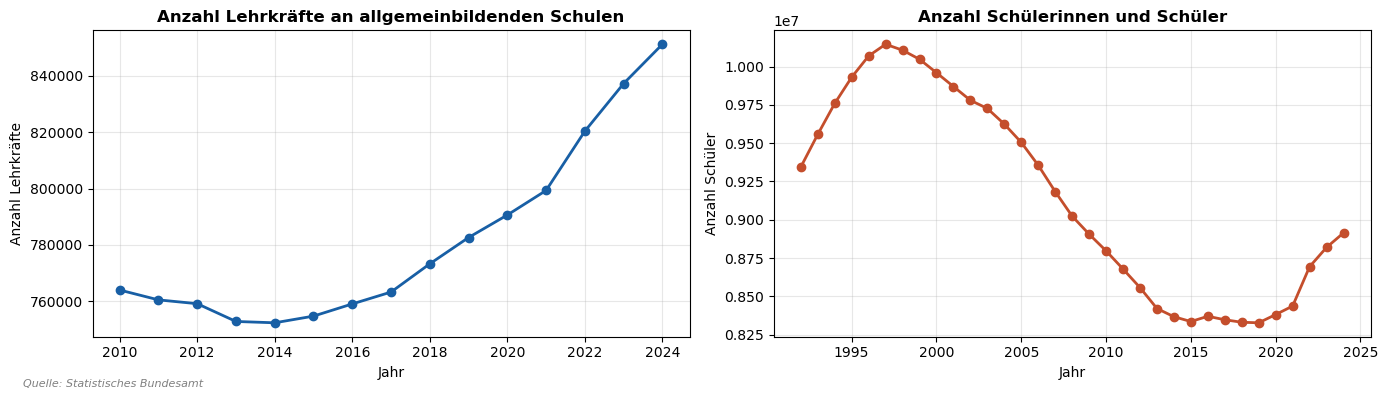

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Lehrer
ax1.plot(lehrer_df['Jahr'], lehrer_df['Anzahl_Lehrer'], marker='o', color='#185FA5', linewidth=2)
ax1.set_title('Anzahl Lehrkräfte an allgemeinbildenden Schulen', fontweight='bold')
ax1.set_xlabel('Jahr')
ax1.set_ylabel('Anzahl Lehrkräfte')
ax1.grid(True, alpha=0.3)

# Schüler
ax2.plot(schueler_df['Jahr'], schueler_df['Anzahl_Schueler'], marker='o', color='#C44E2C', linewidth=2)
ax2.set_title('Anzahl Schülerinnen und Schüler', fontweight='bold')
ax2.set_xlabel('Jahr')
ax2.set_ylabel('Anzahl Schüler')
ax2.grid(True, alpha=0.3)

plt.figtext(0.02, 0.02, 'Quelle: Statistisches Bundesamt', fontsize=8, style='italic', color='gray')
plt.tight_layout()
plt.show()

## 10. Block B — Heterogenität: Inklusionsschüler

### Vorgehen

   10.1. Datei einlesen mit der Hilfsfunktion
   10.2. Datentypen sicherstellen
   10.3. Eine saubere CSV-Datei exportieren

Diese Daten zeigen die wachsende Heterogenität in den Klassen — ein zentrales Argument 
der Storyline: Die Aufgaben der Lehrer werden komplexer, nicht nur zahlenmäßig mehr.

In [32]:
inklusion_df = lade_statista_datei(datei_inklusion, "Jahr", "Inklusionsschueler")
inklusion_df['Inklusionsschueler'] = inklusion_df['Inklusionsschueler'].astype(int)

print(f"✓ Inklusionsschüler-Daten: {len(inklusion_df)} Jahre ({inklusion_df['Jahr'].min()}-{inklusion_df['Jahr'].max()})")

✓ Inklusionsschüler-Daten: 15 Jahre (2009-2023)


### Visualisierung Block B — Entwicklung der Inklusion

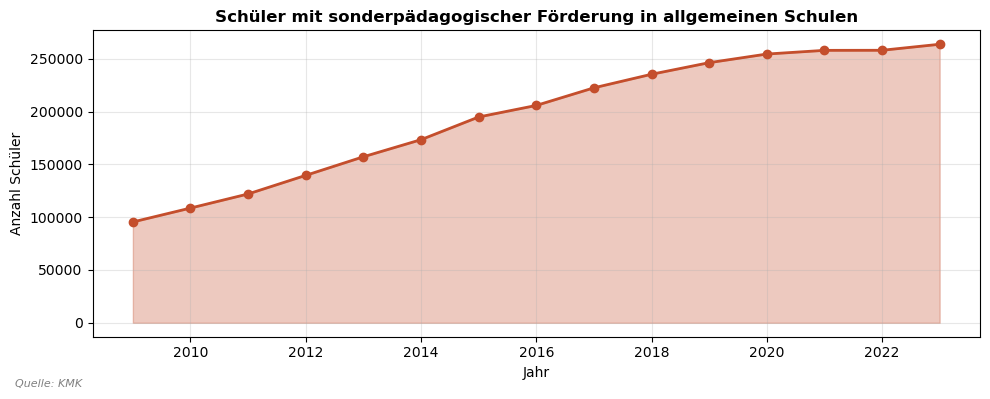

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(inklusion_df['Jahr'], inklusion_df['Inklusionsschueler'], 
                alpha=0.3, color='#C44E2C')
ax.plot(inklusion_df['Jahr'], inklusion_df['Inklusionsschueler'], 
        marker='o', color='#C44E2C', linewidth=2)
ax.set_title('Schüler mit sonderpädagogischer Förderung in allgemeinen Schulen', fontweight='bold')
ax.set_xlabel('Jahr')
ax.set_ylabel('Anzahl Schüler')
ax.grid(True, alpha=0.3)

plt.figtext(0.02, 0.02, 'Quelle: KMK', fontsize=8, style='italic', color='gray')
plt.tight_layout()
plt.show()

## 11. Block C — Wahrnehmung der Lehrkräfte

### Vorgehen

   11.1. Datei einlesen
   11.2. Nach Häufigkeit sortieren (für klare Visualisierung)
   11.3. CSV-Datei exportieren

Diese Daten habe ich aus dem **Statista-Report "Lehrkräftemangel in Deutschland" (2024)** 
extrahiert (Diagramm "Was sind die größten Herausforderungen der Lehrkräfte?"). 

Quelle: Robert Bosch Stiftung, Schulbarometer 2024, 1.540 befragte Lehrkräfte.

herausforderungen_df = lade_statista_datei(datei_herausforderungen, "Herausforderung", "Anteil_Prozent")

# Nach Häufigkeit absteigend sortieren
herausforderungen_df = herausforderungen_df.sort_values('Anteil_Prozent', ascending=False).reset_index(drop=True)

print(f"✓ Herausforderungen-Daten: {len(herausforderungen_df)} Einträge")

### Visualisierung Block C — Herausforderungen der Lehrkräfte

In [42]:
herausforderungen_df = lade_statista_datei(datei_herausforderungen, "Herausforderung", "Anteil_Prozent")

# Nach Häufigkeit absteigend sortieren
herausforderungen_df = herausforderungen_df.sort_values('Anteil_Prozent', ascending=False).reset_index(drop=True)

print(f"✓ Herausforderungen-Daten: {len(herausforderungen_df)} Einträge")

✓ Herausforderungen-Daten: 10 Einträge


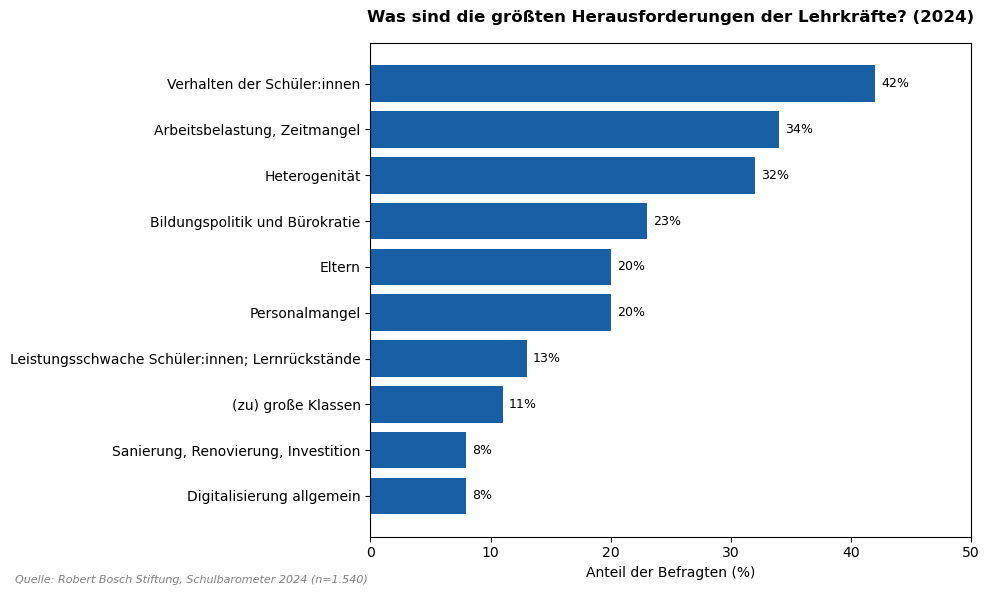

In [43]:
df_plot = herausforderungen_df.sort_values('Anteil_Prozent', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_plot['Herausforderung'], df_plot['Anteil_Prozent'], color='#185FA5')

ax.set_xlabel('Anteil der Befragten (%)')
ax.set_title('Was sind die größten Herausforderungen der Lehrkräfte? (2024)', 
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlim(0, 50)

# Werte am Ende der Balken anzeigen
for i, (idx, row) in enumerate(df_plot.iterrows()):
    ax.text(row['Anteil_Prozent'] + 0.5, i, f"{row['Anteil_Prozent']}%", 
            va='center', fontsize=9)

plt.figtext(0.02, 0.02, 'Quelle: Robert Bosch Stiftung, Schulbarometer 2024 (n=1.540)', 
            fontsize=8, style='italic', color='gray')
plt.tight_layout()
plt.show()

## 12. Block D — Wahrnehmung der Schulleitungen

### Vorgehen

   12.1. Datei einlesen
   12.2. Nach Häufigkeit sortieren
   12.3. CSV-Datei exportieren

Diese Daten habe ich aus dem **Statista-Report** extrahiert (Diagramm "Umfrage zur 
Belastung von Schulleitungen"). 

Quelle: Verband Bildung und Erziehung (VBE), 2024, 1.311 befragte Schulleitungen.

In [45]:
belastung_df = lade_statista_datei(datei_belastung, "Belastungsfaktor", "Anteil_Prozent")
belastung_df = belastung_df.sort_values('Anteil_Prozent', ascending=False).reset_index(drop=True)

print(f"✓ Belastungsfaktoren-Daten: {len(belastung_df)} Einträge")

✓ Belastungsfaktoren-Daten: 11 Einträge


In [47]:
### Visualisierung Block D — Belastungsfaktoren der Schulleitungen

df_plot = belastung_df.sort_values('Anteil_Prozent', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_plot['Belastungsfaktor'], df_plot['Anteil_Prozent'], color='#185FA5')

ax.set_xlabel('Anteil der befragten Schulleitungen (%)')
ax.set_title('Wodurch fühlen sich Schulleitungen (sehr) stark belastet? (2024)', 
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlim(0, 105)

for i, (idx, row) in enumerate(df_plot.iterrows()):
    ax.text(row['Anteil_Prozent'] + 1, i, f"{row['Anteil_Prozent']}%", 
            va='center', fontsize=9)

plt.figtext(0.02, 0.02, 'Quelle: Verband Bildung und Erziehung (VBE), 2024 (n=1.311)', 
            fontsize=8, style='italic', color='gray')
plt.tight_layout()
plt.show()

## 13. Block E — Symptome des Mangels

### 13.1. Unbesetzte Lehrkräftestellen über die Zeit

Diese Daten habe ich aus dem **Statista-Report** extrahiert. Sie zeigen den Anteil 
der Schulen, die mit *schwerem* Lehrermangel kämpfen (über 15% unbesetzter Stellen).

mangel_zeit_df = lade_statista_datei(datei_mangel_zeit, "Jahr", "Anteil_starker_Mangel")
mangel_zeit_df['Jahr'] = mangel_zeit_df['Jahr'].astype(int)

print(f"✓ Lehrermangel-Zeitreihe: {len(mangel_zeit_df)} Jahre")

### Visualisierung E.1 — Entwicklung des starken Lehrermangels

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(mangel_zeit_df['Jahr'], mangel_zeit_df['Anteil_starker_Mangel'], 
       color='#C44E2C', edgecolor='white')

ax.set_xlabel('Jahr')
ax.set_ylabel('Anteil der Schulen (%)')
ax.set_title('Anteil Schulen mit über 15% unbesetzter Lehrkräftestellen (2018-2024)', 
             fontsize=12, fontweight='bold', pad=15)
ax.set_ylim(0, 30)

for idx, row in mangel_zeit_df.iterrows():
    ax.text(row['Jahr'], row['Anteil_starker_Mangel'] + 0.5, 
            f"{int(row['Anteil_starker_Mangel'])}%", ha='center', fontsize=9)

plt.figtext(0.02, 0.02, 'Quelle: Verband Bildung und Erziehung (VBE)', 
            fontsize=8, style='italic', color='gray')
plt.tight_layout()
plt.show()

### 13.2. Krankheitsbedingte Ausfälle

Diese Daten zeigen, wie sich die Wahrnehmung der Schulleitungen bezüglich 
langfristiger Krankschreibungen im Kollegium über die Zeit entwickelt hat 
(2019 → 2021 → 2023). 

Sowohl physische als auch psychische Erkrankungen haben deutlich zugenommen.

In [55]:
erkrankungen_df = lade_statista_datei(datei_erkrankungen, "Jahr_Typ", "Anteil_Schulleitungen")

print(f"✓ Erkrankungen-Daten: {len(erkrankungen_df)} Einträge")

✓ Erkrankungen-Daten: 6 Einträge


### Visualisierung E.2 — Zunahme krankheitsbedingter Ausfälle

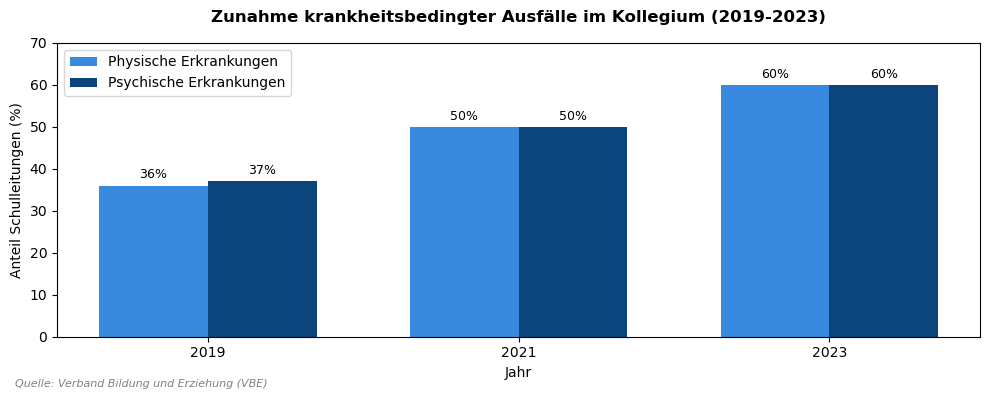

In [56]:
# Daten in passendes Format für gruppiertes Balkendiagramm
jahre = [2019, 2021, 2023]
physisch = [36, 50, 60]
psychisch = [37, 50, 60]

x = np.arange(len(jahre))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
balken1 = ax.bar(x - width/2, physisch, width, label='Physische Erkrankungen', color='#378ADD')
balken2 = ax.bar(x + width/2, psychisch, width, label='Psychische Erkrankungen', color='#0C447C')

ax.set_xlabel('Jahr')
ax.set_ylabel('Anteil Schulleitungen (%)')
ax.set_title('Zunahme krankheitsbedingter Ausfälle im Kollegium (2019-2023)', 
             fontsize=12, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(jahre)
ax.set_ylim(0, 70)
ax.legend()

for balken in [balken1, balken2]:
    for b in balken:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 1, f'{int(h)}%', 
                ha='center', va='bottom', fontsize=9)

plt.figtext(0.02, 0.02, 'Quelle: Verband Bildung und Erziehung (VBE)', 
            fontsize=8, style='italic', color='gray')
plt.tight_layout()
plt.show()

## 14. Block F — Leistungsergebnisse: PISA

### Vorgehen

   14.1. Die drei PISA-Dateien einlesen (Mathematik, Lesekompetenz, Naturwissenschaften)
   14.2. Sie in einem einzigen DataFrame zusammenführen (gemeinsamer Schlüssel: Jahr)
   14.3. CSV-Datei exportieren

Hier ist ein **Merge sinnvoll**, weil die drei Datensätze die gleichen Jahre teilen 
und in einer einzelnen Grafik gut vergleichbar sind.

In [58]:
pisa_mathe_df = lade_statista_datei(datei_pisa_mathe, "Jahr", "PISA_Mathematik")
pisa_lesen_df = lade_statista_datei(datei_pisa_lesen, "Jahr", "PISA_Lesekompetenz")
pisa_nawi_df  = lade_statista_datei(datei_pisa_nawi,  "Jahr", "PISA_Naturwissenschaften")

# Die 3 DataFrames anhand der Jahr-Spalte zusammenführen
pisa_df = pisa_mathe_df.merge(pisa_lesen_df, on='Jahr', how='outer')
pisa_df = pisa_df.merge(pisa_nawi_df, on='Jahr', how='outer')
pisa_df = pisa_df.sort_values('Jahr').reset_index(drop=True)

print(f"✓ PISA-Daten zusammengeführt: {len(pisa_df)} Jahre")

✓ PISA-Daten zusammengeführt: 8 Jahre


### Visualisierung Block F — PISA-Ergebnisse

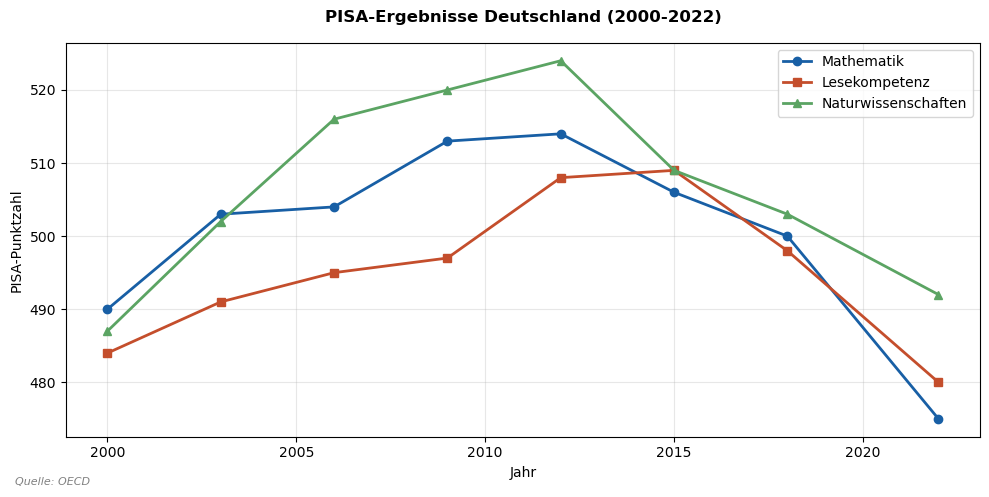

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(pisa_df['Jahr'], pisa_df['PISA_Mathematik'], 
        marker='o', linewidth=2, label='Mathematik', color='#185FA5')
ax.plot(pisa_df['Jahr'], pisa_df['PISA_Lesekompetenz'], 
        marker='s', linewidth=2, label='Lesekompetenz', color='#C44E2C')
ax.plot(pisa_df['Jahr'], pisa_df['PISA_Naturwissenschaften'], 
        marker='^', linewidth=2, label='Naturwissenschaften', color='#5BA463')

ax.set_xlabel('Jahr')
ax.set_ylabel('PISA-Punktzahl')
ax.set_title('PISA-Ergebnisse Deutschland (2000-2022)', 
             fontsize=12, fontweight='bold', pad=15)
ax.legend()
ax.grid(True, alpha=0.3)

plt.figtext(0.02, 0.02, 'Quelle: OECD', fontsize=8, style='italic', color='gray')
plt.tight_layout()
plt.show()

## 15. Export der aufbereiteten Daten

Jeder thematische Block wird in einer **eigenen CSV-Datei** gespeichert. 
So können die Visualisierungs-Kollegen gezielt mit den Daten arbeiten, 
die sie brauchen — **ohne** mit einer großen unübersichtlichen Tabelle 
hantieren zu müssen.

In [66]:
# Block E.1 — Unbesetzte Lehrkräftestellen laden
mangel_zeit_df = lade_statista_datei(datei_mangel_zeit, "Jahr", "Anteil_starker_Mangel")
mangel_zeit_df['Jahr'] = mangel_zeit_df['Jahr'].astype(int)

# Block E.2 — Erkrankungen laden
erkrankungen_df = lade_statista_datei(datei_erkrankungen, "Jahr_Typ", "Anteil_Schulleitungen")

# Block F — PISA laden et fusionnen
pisa_mathe_df = lade_statista_datei(datei_pisa_mathe, "Jahr", "PISA_Mathematik")
pisa_lesen_df = lade_statista_datei(datei_pisa_lesen, "Jahr", "PISA_Lesekompetenz")
pisa_nawi_df  = lade_statista_datei(datei_pisa_nawi,  "Jahr", "PISA_Naturwissenschaften")

pisa_df = pisa_mathe_df.merge(pisa_lesen_df, on='Jahr', how='outer')
pisa_df = pisa_df.merge(pisa_nawi_df, on='Jahr', how='outer')
pisa_df = pisa_df.sort_values('Jahr').reset_index(drop=True)

print("✓ Toutes les variables manquantes chargées :")
print(f"   - mangel_zeit_df: {len(mangel_zeit_df)} lignes")
print(f"   - erkrankungen_df: {len(erkrankungen_df)} lignes")
print(f"   - pisa_df: {len(pisa_df)} lignes")

✓ Toutes les variables manquantes chargées :
   - mangel_zeit_df: 7 lignes
   - erkrankungen_df: 6 lignes
   - pisa_df: 8 lignes


## 16. Zusammenfassung der Datenaufbereitung

### Was wurde gemacht?

   16.1. **Einheitliche Hilfsfunktion** definiert, um alle Statista-Dateien mit demselben Code zu laden
   16.2. **6 vorhandene Datensätze** bereinigt (Lehrer, Schüler, Inklusion, 3× PISA)
   16.3. **4 neue Datensätze** zur Wahrnehmung des Lehrermangels aus dem Statista-Report extrahiert und in das gleiche Format gebracht
   16.4. **Schuljahre normalisiert** (`"2010/11"` → `2010`) für saubere Merges
   16.5. **PISA-Daten zusammengeführt** (sinnvoll, da gleiche Jahre)
   16.6. Alle Daten in **8 thematischen CSV-Dateien** exportiert, entlang der Storyline organisiert

### Dateien für die Visualisierungs-Kollegen

| Datei | Inhalt |
|-------|--------|
| `A_kapazitaet_lehrer.csv` | Anzahl Lehrer über die Jahre |
| `A_kapazitaet_schueler.csv` | Anzahl Schüler über die Jahre |
| `B_heterogenitaet_inklusion.csv` | Inklusionsschüler über die Jahre |
| `C_wahrnehmung_lehrkraefte.csv` | Herausforderungen aus Sicht der Lehrkräfte (2024) |
| `D_wahrnehmung_schulleitungen.csv` | Belastungsfaktoren der Schulleitungen (2024) |
| `E1_symptome_unbesetzte_stellen.csv` | Entwicklung des Lehrermangels über die Jahre |
| `E2_symptome_erkrankungen.csv` | Krankheitsbedingte Ausfälle (2019-2023) |
| `F_leistungsergebnisse_pisa.csv` | PISA-Ergebnisse (Mathe/Lesen/Nawi) |

Die in diesem Notebook gezeigten Diagramme sind **nur Vorschau-Visualisierungen** 
zur Qualitätskontrolle. Die finalen Visualisierungen für die Präsentation werden 
von den Kollegen erstellt.